# 量化可视化 Demo

基于已处理好的数据，展示量价因子分析、IC 分析、回测结果的可视化图表。
无需重新运行因子构建和回测，直接读取 `data/processed/` 下的 CSV 文件即可。

In [74]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# macOS 中文显示
for _f in ["/System/Library/Fonts/PingFang.ttc", "/System/Library/Fonts/STHeiti Light.ttc", 
           "/System/Library/Fonts/STHeiti Medium.ttc", "/System/Library/Fonts/Supplemental/Arial Unicode.ttf"]:
    try:
        from matplotlib.font_manager import fontManager
        fontManager.addfont(_f)
        break
    except Exception:
        continue
plt.rcParams["font.sans-serif"] = ["PingFang SC", "STHeiti", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

%matplotlib inline

In [75]:
clean = pd.read_csv(PROCESSED_DIR / "clean_daily_data.csv", parse_dates=["date"])
factor_panel = pd.read_csv(PROCESSED_DIR / "factor_panel.csv", parse_dates=["date"])
ic_daily = pd.read_csv(PROCESSED_DIR / "factor_ic_daily.csv", parse_dates=["date"])
ic_summary = pd.read_csv(PROCESSED_DIR / "factor_ic_summary.csv")
bt = pd.read_csv(PROCESSED_DIR / "backtest_nav.csv", parse_dates=["date"])

# ret_1d 由 pct_change 转换 (clean_daily_data.csv 不直接包含 ret_1d)
clean["ret_1d"] = clean["pct_change"] / 100

clean.head(2)

,date,ticker,open,high,low,close,volume,amount,pct_change,turnover,ret_1d
0,2016-01-04,300014,8.366130,8.562625,7.441599,7.441599,25489850,798210864.0,-9.9939,7.478224,-0.099939
1,2016-01-05,300014,6.809289,7.368543,6.698446,6.965477,26888282,747134080.0,-6.3981,7.888496,-0.063981


---
## 1. 市场概览

等权指数走势、每日股票数量、日内收益分布。

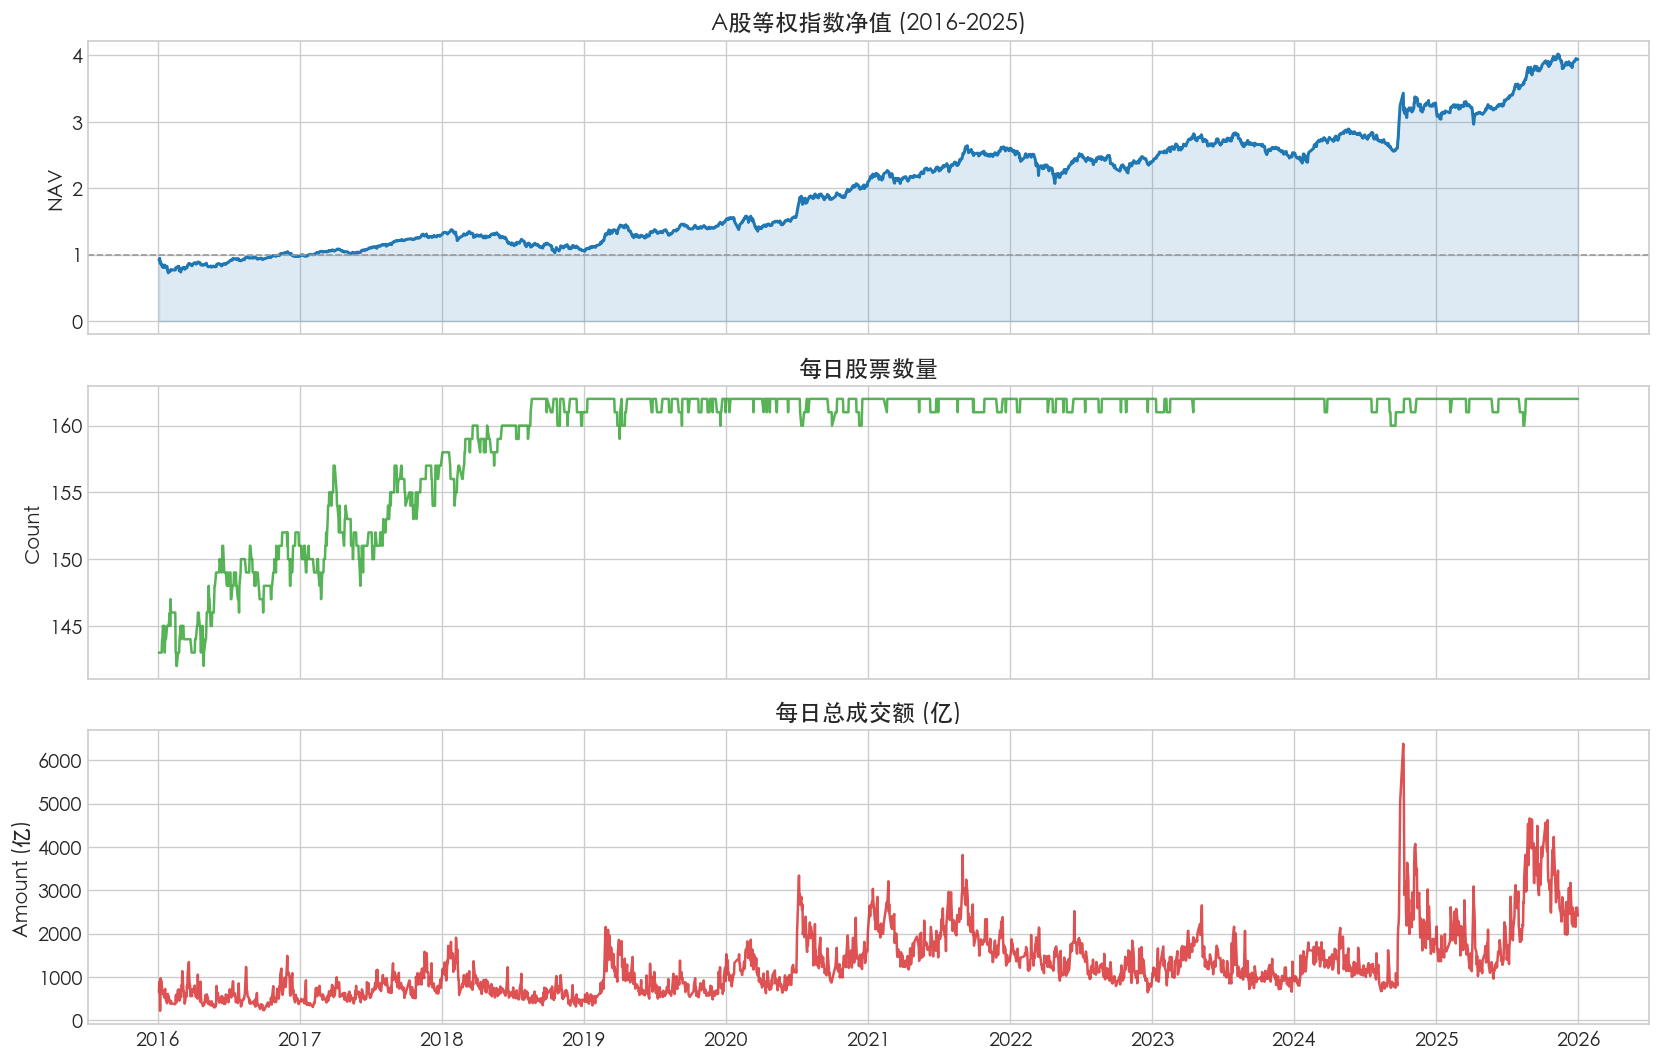

In [76]:
daily_stats = clean.groupby("date").agg(
    n_stocks=("ticker", "nunique"),
    ew_ret=("ret_1d", "mean"),
    total_amount=("amount", "sum"),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(daily_stats["date"], (1 + daily_stats["ew_ret"].fillna(0)).cumprod(),
             color="#1f77b4", linewidth=1.8)
axes[0].fill_between(daily_stats["date"], (1 + daily_stats["ew_ret"].fillna(0)).cumprod(),
                     alpha=0.15, color="#1f77b4")
axes[0].set_title("A股等权指数净值 (2016-2025)", fontweight="bold")
axes[0].set_ylabel("NAV")
axes[0].axhline(y=1, color="#999", linestyle="--", linewidth=1)

axes[1].plot(daily_stats["date"], daily_stats["n_stocks"],
             color="#2ca02c", linewidth=1.5, alpha=0.8)
axes[1].set_title("每日股票数量")
axes[1].set_ylabel("Count")

axes[2].plot(daily_stats["date"], daily_stats["total_amount"] / 1e8,
             color="#d62728", linewidth=1.5, alpha=0.8)
axes[2].set_title("每日总成交额 (亿)")
axes[2].set_ylabel("Amount (亿)")
axes[2].xaxis.set_major_locator(mdates.YearLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

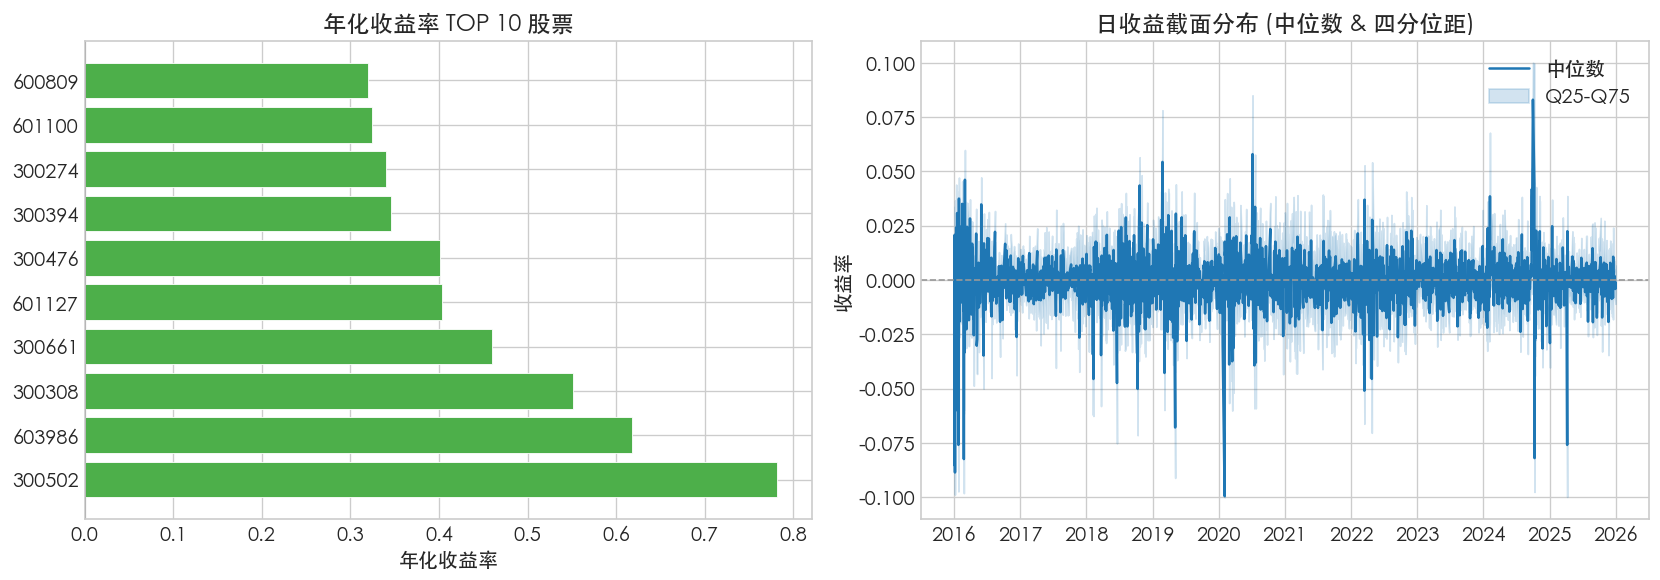

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_tickers = (clean.groupby("ticker").agg(
    ann_ret=("ret_1d", lambda x: (1 + x.dropna()).prod() ** (252 / max(len(x.dropna()), 1)) - 1)
).reset_index().sort_values("ann_ret", ascending=False).head(10))

colors = ["#e41a1c" if v < 0 else "#4daf4a" for v in top_tickers["ann_ret"]]
axes[0].barh(top_tickers["ticker"].astype(str), top_tickers["ann_ret"],
             color=colors, edgecolor="white", linewidth=0.5)
axes[0].axvline(x=0, color="#333", linewidth=1)
axes[0].set_title("年化收益率 TOP 10 股票")
axes[0].set_xlabel("年化收益率")

ret_hist = clean.dropna(subset=["ret_1d"]).groupby("date")["ret_1d"].quantile([0.25, 0.5, 0.75]).unstack()
ret_hist.columns = ["q25", "q50", "q75"]
ret_hist = ret_hist.reset_index()

axes[1].plot(ret_hist["date"], ret_hist["q50"], color="#1f77b4", linewidth=1.5, label="中位数")
axes[1].fill_between(ret_hist["date"], ret_hist["q25"], ret_hist["q75"],
                     alpha=0.2, color="#1f77b4", label="Q25-Q75")
axes[1].axhline(y=0, color="#999", linestyle="--", linewidth=1)
axes[1].set_title("日收益截面分布 (中位数 & 四分位距)")
axes[1].set_ylabel("收益率")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

---
## 2. 因子 IC 分析

展示各因子的 IC 均值、IC 时间序列和累计 IC。

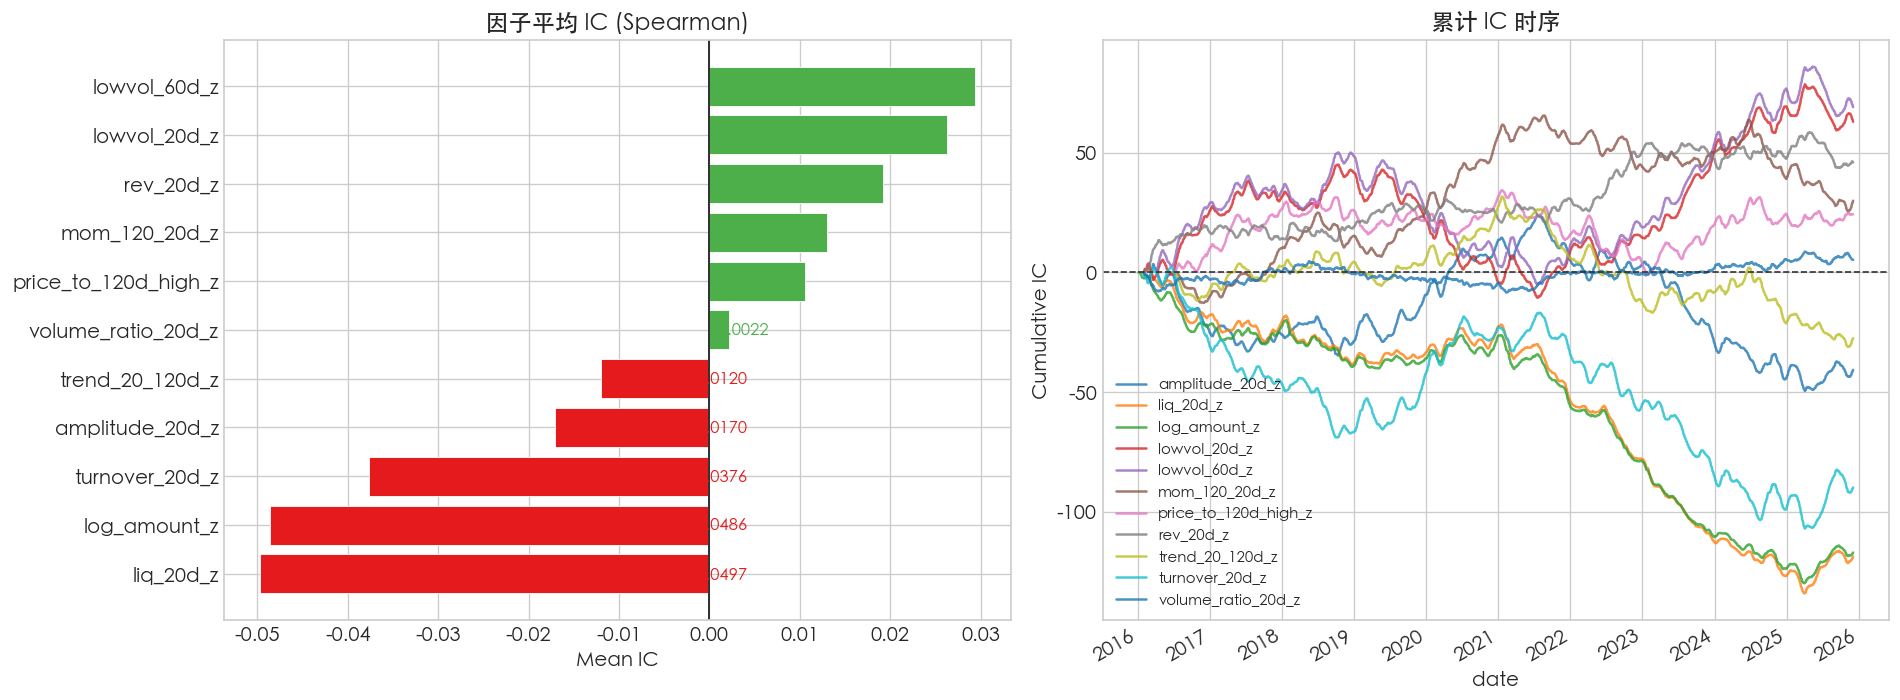

In [78]:
ic_summary_sorted = ic_summary.sort_values("ic_mean", ascending=True).copy()
ic_bar_colors = ["#e41a1c" if v < 0 else "#4daf4a" for v in ic_summary_sorted["ic_mean"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(ic_summary_sorted["factor"], ic_summary_sorted["ic_mean"],
             color=ic_bar_colors, edgecolor="white", linewidth=0.5)
axes[0].axvline(x=0, color="#333", linewidth=1.2)
axes[0].set_title("因子平均 IC (Spearman)", fontweight="bold")
axes[0].set_xlabel("Mean IC")
for i, (_, row) in enumerate(ic_summary_sorted.iterrows()):
    axes[0].text(
        -0.002 if row["ic_mean"] < 0 else 0.001,
        i, f"{row['ic_mean']:.4f}",
        va="center", fontsize=10, fontweight="bold",
        color="#e41a1c" if row["ic_mean"] < 0 else "#4daf4a"
    )

ic_pivot = ic_daily.pivot(index="date", columns="factor", values="ic")
ic_cumsum = ic_pivot.cumsum()
ic_cumsum.plot(ax=axes[1], linewidth=1.5, alpha=0.8)
axes[1].axhline(y=0, color="#333", linestyle="--", linewidth=1)
axes[1].set_title("累计 IC 时序", fontweight="bold")
axes[1].set_ylabel("Cumulative IC")
axes[1].legend(loc="best", fontsize=9)
axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

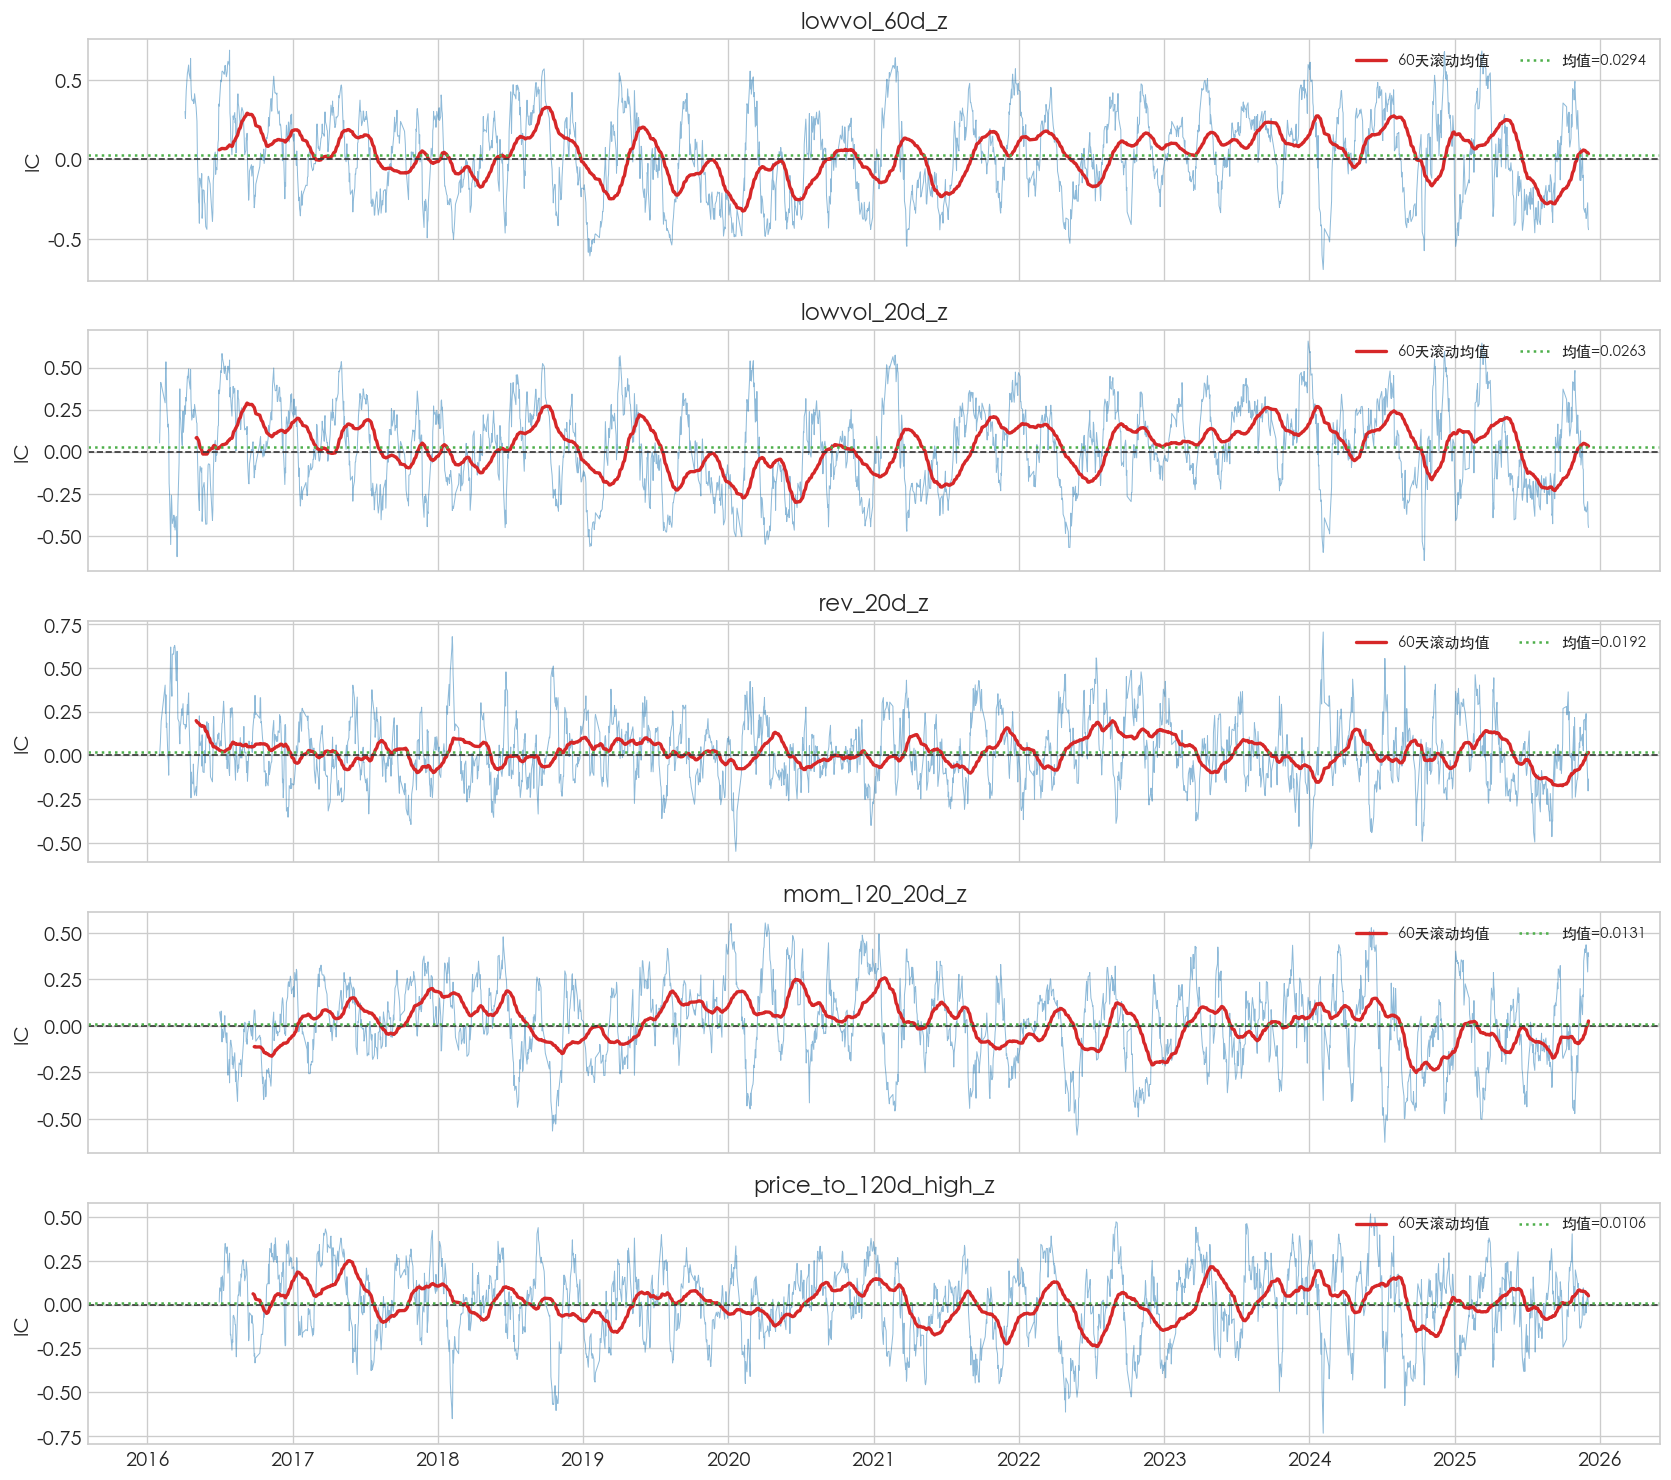

In [79]:
top_factors = ic_summary.nlargest(5, "ic_ir")["factor"].tolist()

fig, axes = plt.subplots(len(top_factors), 1, figsize=(14, 2.5 * len(top_factors)), sharex=True)

for ax, factor in zip(axes, top_factors):
    sub = ic_daily[ic_daily["factor"] == factor].copy()
    ax.plot(sub["date"], sub["ic"], linewidth=0.6, alpha=0.5, color="#1f77b4")
    ax.plot(sub["date"], sub["ic"].rolling(60).mean(),
            linewidth=2, color="#d62728", label="60天滚动均值")
    ax.axhline(y=0, color="#333", linestyle="--", linewidth=1)
    mean_ic = sub["ic"].mean()
    ax.axhline(y=mean_ic, color="#4daf4a", linestyle=":", linewidth=1.5,
               label=f"均值={mean_ic:.4f}")
    ax.set_ylabel("IC")
    ax.set_title(f"{factor}", fontweight="bold")
    ax.legend(loc="upper right", fontsize=9, ncol=2)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

---
## 3. 因子分位数收益

最佳因子的多空分组收益分析。

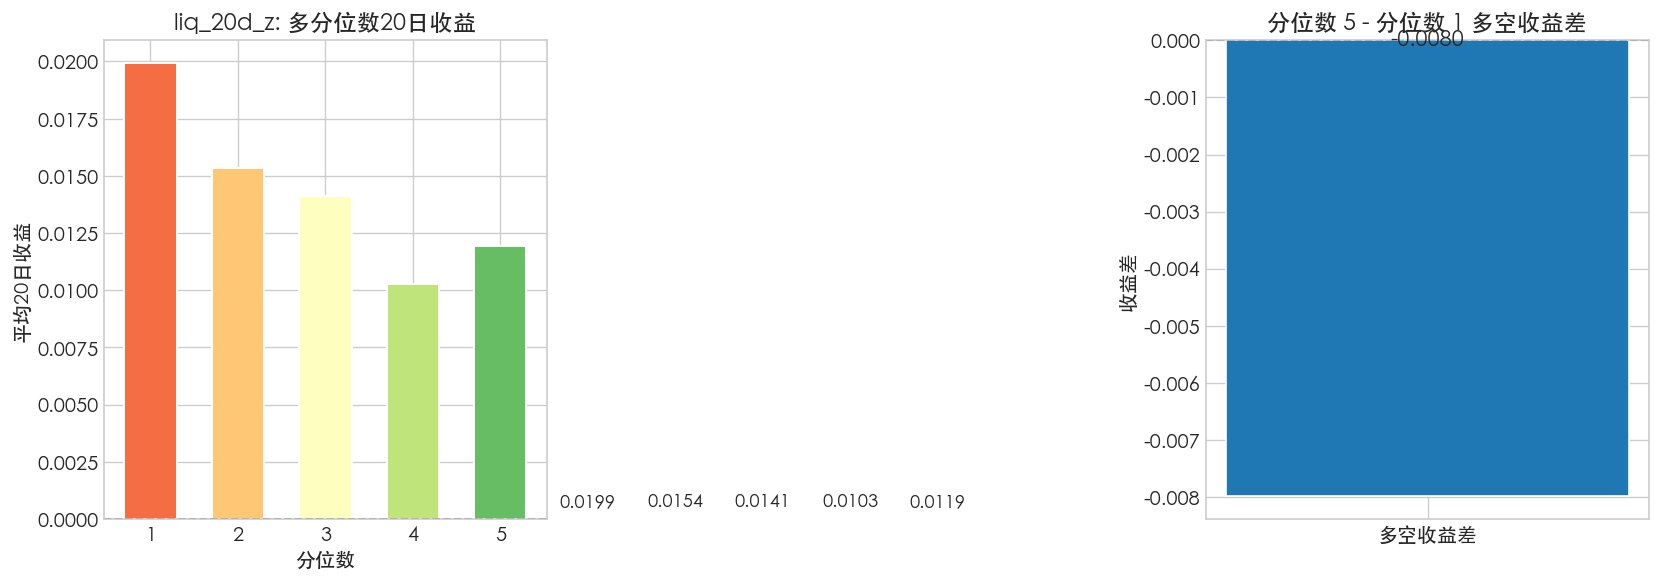

最佳因子: liq_20d_z
多空收益差 (Q5 - Q1): -0.0080


In [80]:
from scripts.factor_evaluation import quantile_return_analysis

best_factor = ic_summary.iloc[0]["factor"]
qret = quantile_return_analysis(factor_panel, best_factor, forward_return_col="fwd_ret_20d")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_q = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(qret)))
axes[0].bar(qret["quantile"].astype(str), qret["mean_return"],
            color=colors_q, edgecolor="white", linewidth=1.2, width=0.6)
axes[0].axhline(y=0, color="#333", linestyle="--", linewidth=1.2)
for _, row in qret.iterrows():
    axes[0].text(
        str(row["quantile"]), 0.0005 if row["mean_return"] >= 0 else -0.0005,
        f"{row['mean_return']:.4f}", ha="center", fontsize=11, fontweight="bold"
    )
axes[0].set_title(f"{best_factor}: 多分位数20日收益", fontweight="bold")
axes[0].set_xlabel("分位数")
axes[0].set_ylabel("平均20日收益")

spread = qret.iloc[-1]["mean_return"] - qret.iloc[0]["mean_return"]
axes[1].bar(["多空收益差"], [spread], color="#1f77b4", width=0.4, edgecolor="white")
axes[1].axhline(y=0, color="#333", linestyle="--", linewidth=1.2)
axes[1].text(0, 0.0001 if spread >= 0 else -0.0001,
             f"{spread:.4f}", ha="center", fontsize=13, fontweight="bold")
axes[1].set_title("分位数 5 - 分位数 1 多空收益差", fontweight="bold")
axes[1].set_ylabel("收益差")

plt.tight_layout()
plt.show()

print(f"最佳因子: {best_factor}")
print(f"多空收益差 (Q5 - Q1): {spread:.4f}")

---
## 4. 多因子组合热力图

展示各因子之间的截面相关性。

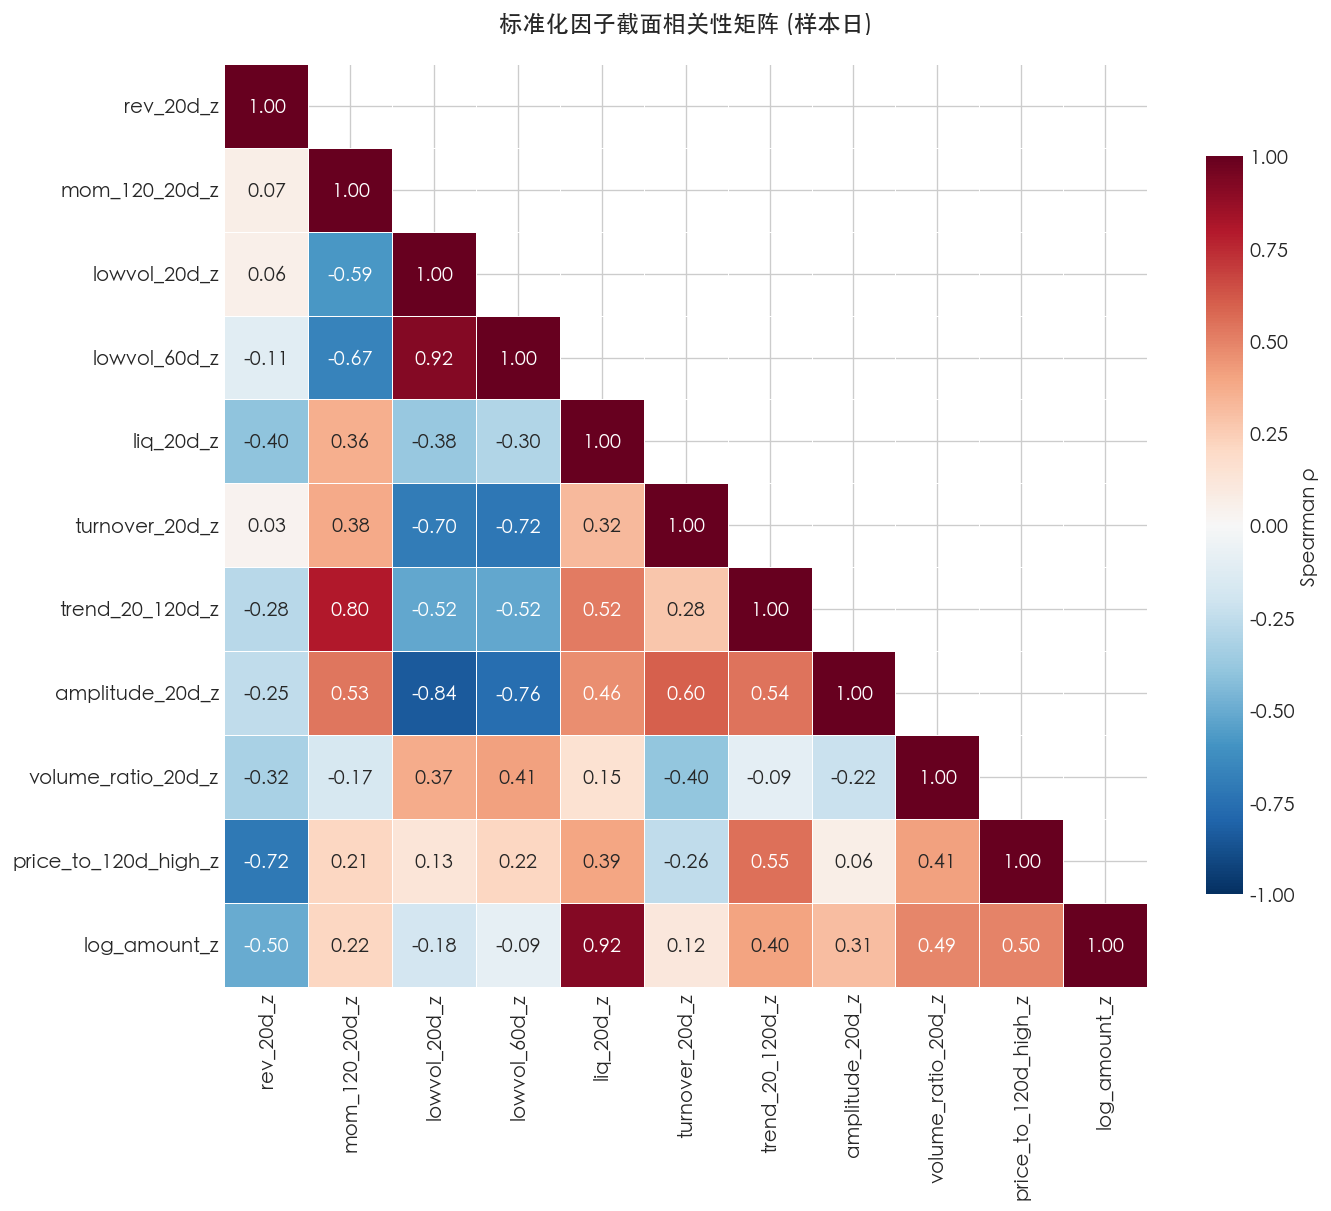

In [81]:
factor_cols = [c for c in factor_panel.columns if c.endswith("_z")]

corr_sample = factor_panel[factor_panel["date"] == factor_panel["date"].iloc[500]][factor_cols]
corr = corr_sample.corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8, "label": "Spearman ρ"},
            ax=ax)
ax.set_title("标准化因子截面相关性矩阵 (样本日)", fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

---
## 5. 回测结果

多空组合净值曲线、累积收益、最大回撤。

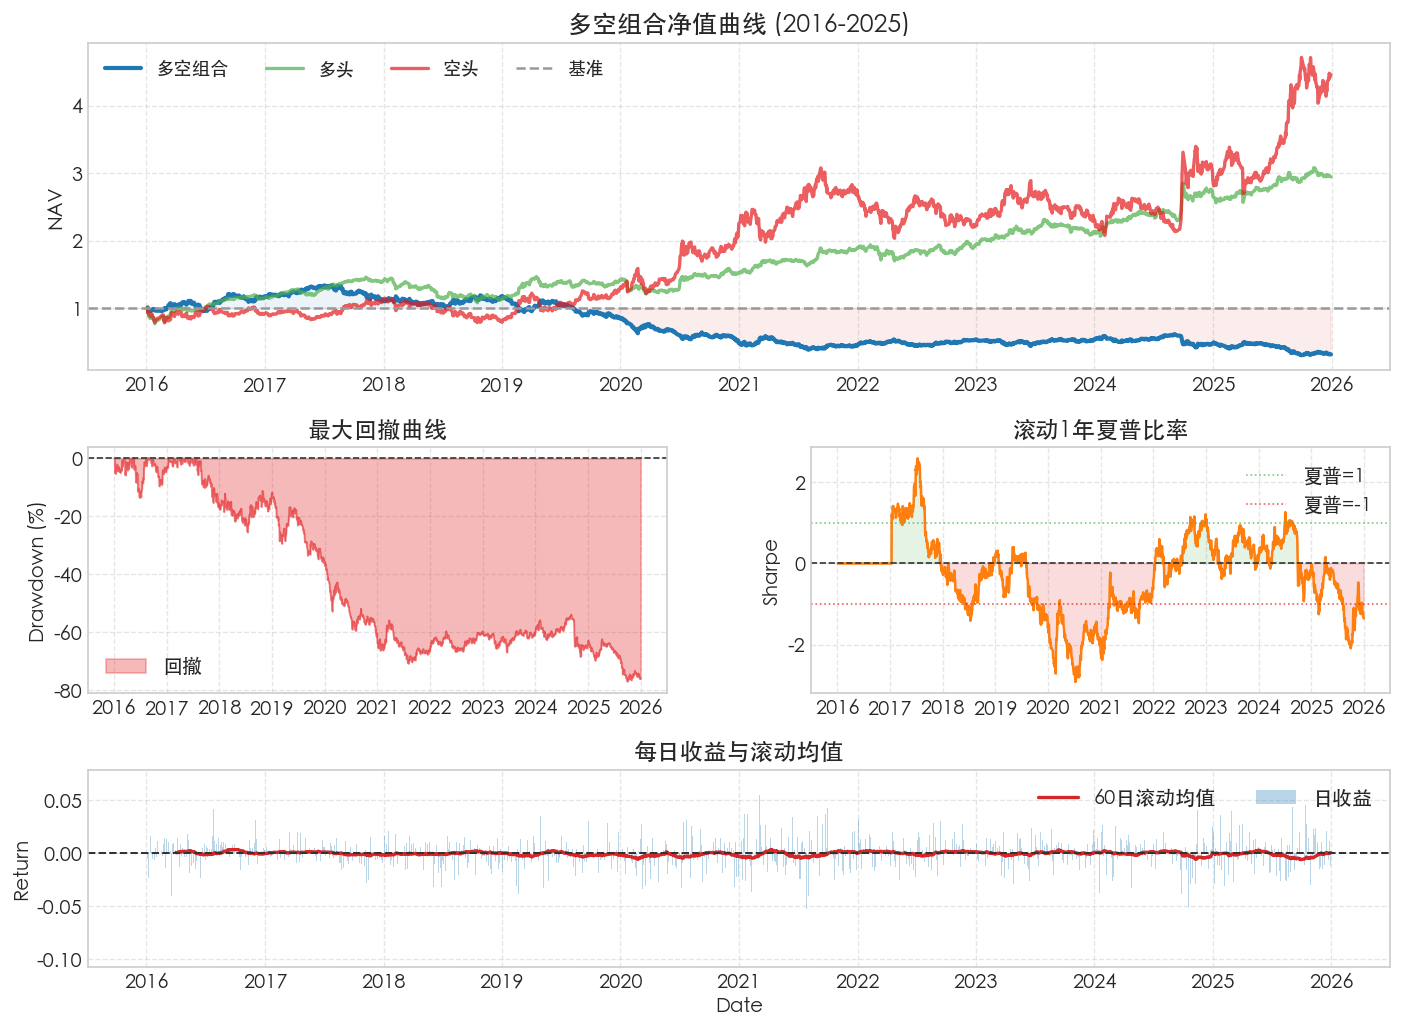

In [82]:
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1.5, 1.2], hspace=0.3, wspace=0.25)

ax0 = fig.add_subplot(gs[0, :])
ax0.plot(bt["date"], bt["nav"], color="#1f77b4", linewidth=2.5, label="多空组合")
ax0.plot(bt["date"], bt["long_nav"], color="#4daf4a", linewidth=2, alpha=0.7, label="多头")
ax0.plot(bt["date"], bt["short_nav"], color="#e41a1c", linewidth=2, alpha=0.7, label="空头")
ax0.axhline(y=1, color="#999", linestyle="--", linewidth=1.5, label="基准")
ax0.fill_between(bt["date"], bt["nav"], 1,
                 where=(bt["nav"] >= 1), color="#1f77b4", alpha=0.08)
ax0.fill_between(bt["date"], bt["nav"], 1,
                 where=(bt["nav"] < 1), color="#e41a1c", alpha=0.08)
ax0.set_title("多空组合净值曲线 (2016-2025)", fontweight="bold", fontsize=15)
ax0.set_ylabel("NAV", fontsize=12)
ax0.legend(fontsize=11, loc="upper left", ncol=4)
ax0.grid(True, linestyle="--", alpha=0.5)

ax1 = fig.add_subplot(gs[1, 0])
bt["cumret"] = (bt["nav"] - 1)
drawdown = bt["nav"] / bt["nav"].cummax() - 1
ax1.fill_between(bt["date"], drawdown * 100, 0,
                 color="#e41a1c", alpha=0.3, label="回撤")
ax1.plot(bt["date"], drawdown * 100, color="#e41a1c", linewidth=1, alpha=0.5)
ax1.axhline(y=0, color="#333", linestyle="--", linewidth=1)
ax1.set_title("最大回撤曲线", fontweight="bold")
ax1.set_ylabel("Drawdown (%)")
ax1.legend(loc="lower left")
ax1.grid(True, linestyle="--", alpha=0.5)

ax2 = fig.add_subplot(gs[1, 1])
rolling_sharpe = (bt["ret"].rolling(252).mean() / bt["ret"].rolling(252).std() * np.sqrt(252)).fillna(0).replace([np.inf, -np.inf], 0)
ax2.plot(bt["date"], rolling_sharpe, color="#ff7f0e", linewidth=1.5)
ax2.axhline(y=0, color="#333", linestyle="--", linewidth=1)
ax2.axhline(y=1, color="#4daf4a", linestyle=":", linewidth=1, alpha=0.7, label="夏普=1")
ax2.axhline(y=-1, color="#e41a1c", linestyle=":", linewidth=1, alpha=0.7, label="夏普=-1")
ax2.fill_between(bt["date"], rolling_sharpe, 0,
                 where=(rolling_sharpe >= 0), color="#4daf4a", alpha=0.15)
ax2.fill_between(bt["date"], rolling_sharpe, 0,
                 where=(rolling_sharpe < 0), color="#e41a1c", alpha=0.15)
ax2.set_title("滚动1年夏普比率", fontweight="bold")
ax2.set_ylabel("Sharpe")
ax2.legend(loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.5)

ax3 = fig.add_subplot(gs[2, :])
bt["cum_ret"] = bt["ret"].rolling(20).mean()
ax3.bar(bt["date"], bt["ret"], width=1, color="#1f77b4", alpha=0.3, label="日收益")
ax3.plot(bt["date"], bt["ret"].rolling(60).mean(),
         color="#d62728", linewidth=2, label="60日滚动均值")
ax3.axhline(y=0, color="#333", linestyle="--", linewidth=1.2)
ax3.set_title("每日收益与滚动均值", fontweight="bold")
ax3.set_ylabel("Return")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right", ncol=2)
ax3.grid(True, linestyle="--", alpha=0.5)

plt.show()

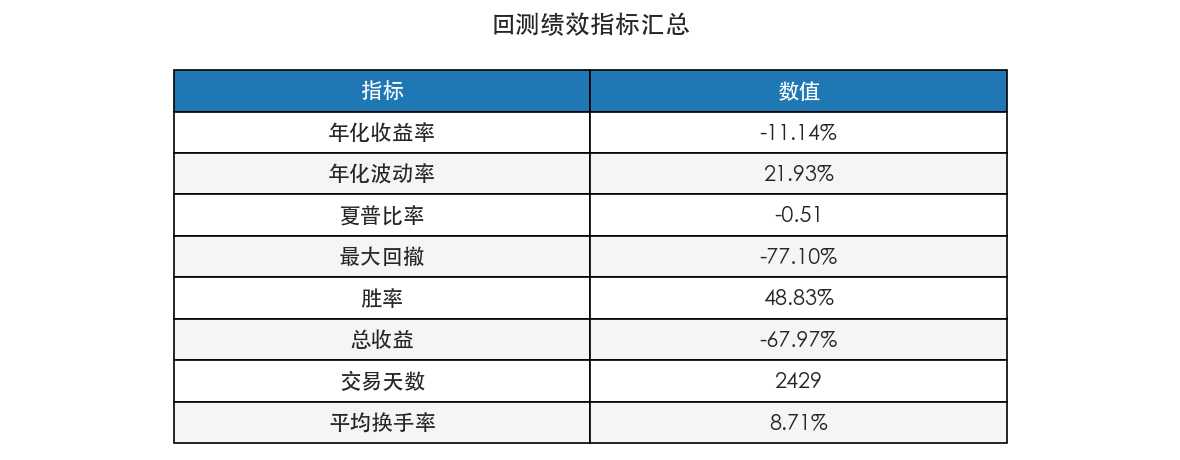

In [83]:
metrics = {
    "年化收益率": f"{bt['nav'].iloc[-1] ** (252 / len(bt)) - 1:.2%}",
    "年化波动率": f"{bt['ret'].std() * np.sqrt(252):.2%}",
    "夏普比率": f"{(bt['nav'].iloc[-1] ** (252 / len(bt)) - 1) / (bt['ret'].std() * np.sqrt(252)):.2f}",
    "最大回撤": f"{(bt['nav'] / bt['nav'].cummax() - 1).min():.2%}",
    "胜率": f"{(bt['ret'] > 0).mean():.2%}",
    "总收益": f"{bt['nav'].iloc[-1] - 1:.2%}",
    "交易天数": f"{len(bt)}",
    "平均换手率": f"{bt['turnover'].mean():.2%}",
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
table_data = [[k, v] for k, v in metrics.items()]
table = ax.table(cellText=table_data, colLabels=["指标", "数值"],
                 loc="center", cellLoc="center", colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.2, 2)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor("#1f77b4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f5f5f5")
ax.set_title("回测绩效指标汇总", fontweight="bold", fontsize=15, pad=20)
plt.tight_layout()
plt.show()